In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [3]:
df = pd.read_csv('new_data.csv')
df.sample(8)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2226526,186,TRANSFER,428768.08,C773234006,0.00,0.00,C93574042,590729.77,1019497.86,0,0
2066949,181,CASH_OUT,371090.47,C572856096,25529.00,0.00,C877056917,115091.49,486181.96,0,0
6046021,492,CASH_OUT,313665.85,C2144353718,18110.00,0.00,C998361395,7705.48,321371.33,0,0
2463705,203,CASH_OUT,428067.94,C1979119574,0.00,0.00,C894373883,5211080.24,5639148.18,0,0
1228886,133,CASH_OUT,130901.69,C178435398,367870.72,236969.03,C454510667,228888.23,359789.92,0,0
1100852,130,PAYMENT,1540.04,C1498715801,192165.45,190625.41,M472212198,0.00,0.00,0,0
4065390,300,PAYMENT,21688.90,C260292924,0.00,0.00,M1932718043,0.00,0.00,0,0
4863584,348,PAYMENT,15949.11,C1389666803,218837.67,202888.56,M238825261,0.00,0.00,0,0


In [4]:
# Filter only fraud transactions
df_fraud = df[df['isFraud'] == 1]

# Show first few rows
print(df_fraud.head())

# Check how many fraud cases exist
print("\nTotal number of fraud transactions:", len(df_fraud))


     step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2       1  TRANSFER    181.0  C1305486145          181.0             0.0   
3       1  CASH_OUT    181.0   C840083671          181.0             0.0   
251     1  TRANSFER   2806.0  C1420196421         2806.0             0.0   
252     1  CASH_OUT   2806.0  C2101527076         2806.0             0.0   
680     1  TRANSFER  20128.0   C137533655        20128.0             0.0   

        nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
2     C553264065             0.0             0.0        1               0  
3      C38997010         21182.0             0.0        1               0  
251   C972765878             0.0             0.0        1               0  
252  C1007251739         26202.0             0.0        1               0  
680  C1848415041             0.0             0.0        1               0  

Total number of fraud transactions: 8213


In [5]:
df_fraud.sample(7)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6281784,650,CASH_OUT,1264551.38,C1956698065,1264551.38,0.0,C1464410535,0.00,1264551.38,1,0
1030532,71,CASH_OUT,91691.75,C1841119507,91691.75,0.0,C1966998418,329117.96,420809.71,1,0
6055692,499,CASH_OUT,488243.65,C1968880739,488243.65,0.0,C897542866,0.00,488243.65,1,0
6362491,732,CASH_OUT,249365.63,C1261928380,249365.63,0.0,C1342636720,0.00,249365.63,1,0
5188037,366,CASH_OUT,1846748.79,C1233106691,1846748.79,0.0,C1805423931,158690.24,2005439.03,1,0
1059679,116,CASH_OUT,522465.43,C1864714673,522465.43,0.0,C64133603,1116912.37,1639377.80,1,0
1512305,153,TRANSFER,234853.95,C1944993034,234853.95,0.0,C2019813234,0.00,0.00,1,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [8]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [9]:
type_mapping = {
    "CASH_OUT": 0,
    "PAYMENT": 1,
    "CASH_IN":2,
    "TRANSFER": 3,
    "DEBIT":4
}

# Apply mapping
df['type_encoded'] = df['type'].map(type_mapping)

df.sample(7)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded
2715765,211,CASH_OUT,249782.26,C2088004479,0.00,0.00,C296410606,1184982.48,1434764.75,0,0,0
2715931,211,CASH_OUT,231042.77,C1541344551,0.00,0.00,C191824297,2485543.48,2830872.39,0,0,0
4878266,348,PAYMENT,18820.19,C53298850,2868.00,0.00,M1242783291,0.00,0.00,0,0,1
2731485,212,PAYMENT,746.94,C599126203,0.00,0.00,M2141912799,0.00,0.00,0,0,1
2007675,179,CASH_OUT,221233.09,C650501640,1577.00,0.00,C2124802282,571918.52,793151.60,0,0,0
2357681,190,CASH_OUT,554553.41,C426545257,130845.79,0.00,C1513301165,2511126.32,3065679.73,0,0,0
1375838,138,TRANSFER,60815.33,C423299727,85332.00,24516.67,C1940938361,2185962.59,2246777.92,0,0,3


In [10]:
df1 = df

In [11]:
# df1["txn_count_same_step"] = df1.groupby(["step", "nameOrig"])["amount"].transform("count")
# df1["unique_senders_same_step"] = df1.groupby(["step", "nameDest"])["nameOrig"].transform("nunique")

# df1.sample(7)

In [12]:
# Count how many times each sender appears
orig_counts = df['nameOrig'].value_counts()

# Filter accounts that appear more than once
repeated_senders = orig_counts[orig_counts >2]

print("Number of repeated senders:", repeated_senders.shape[0])
print(repeated_senders.head(100))   # Show top 10 repeated senders


Number of repeated senders: 15
nameOrig
C1902386530    3
C363736674     3
C545315117     3
C724452879     3
C1784010646    3
C1677795071    3
C1462946854    3
C1999539787    3
C2098525306    3
C400299098     3
C1832548028    3
C1976208114    3
C2051359467    3
C1065307291    3
C1530544995    3
Name: count, dtype: int64


In [13]:
# Step 1: Count how many times each sender appears
orig_counts = df['nameOrig'].value_counts()

# Step 2: Filter accounts that appear more than 2 times
repeated_senders = orig_counts[orig_counts > 1].index   

# Step 3: Filter dataframe to only those repeated senders
df_repeated = df[df['nameOrig'].isin(repeated_senders)]

# Step 4: Count fraud transactions among them
fraud_count = df_repeated['isFraud'].sum()
total_count = df_repeated.shape[0]

print("Total transactions from senders with >2 occurrences:", total_count)
print("Fraudulent transactions from these senders:", fraud_count)
print("Fraud %:", (fraud_count / total_count) * 100)

Total transactions from senders with >2 occurrences: 18611
Fraudulent transactions from these senders: 28
Fraud %: 0.15044865939498148


In [14]:
# Step 1: Count how many times each sender appears
orig_counts = df['nameDest'].value_counts()

# Step 2: Filter accounts that appear more than  equal to 2 times
repeated_senders = orig_counts[orig_counts >= 2].index   

# Step 3: Filter dataframe to only those repeated senders
df_repeated = df[df['nameDest'].isin(repeated_senders)]

# Step 4: Count fraud transactions among them
fraud_count = df_repeated['isFraud'].sum()
total_count = df_repeated.shape[0]

print("Total transactions from senders with >=2 occurrences:", total_count)
print("Fraudulent transactions from these senders:", fraud_count)
print("Fraud %:", (fraud_count / total_count) * 100)

Total transactions from senders with >=2 occurrences: 4099916
Fraudulent transactions from these senders: 5540
Fraud %: 0.13512471962840214


In [15]:
# Step 1: Filter transactions with amount > 500,000
high_amount_txn = df[df['amount'] > 500000]

# Step 2: Count how many of them are fraud
fraud_count = high_amount_txn['isFraud'].sum()
total_count = high_amount_txn.shape[0]

print("Total transactions with amount > 500,000:", total_count)
print("Fraudulent transactions among them:", fraud_count)
print("Fraud %:", (fraud_count / total_count) * 100)


Total transactions with amount > 500,000: 340284
Fraudulent transactions among them: 3864
Fraud %: 1.1355220933102939


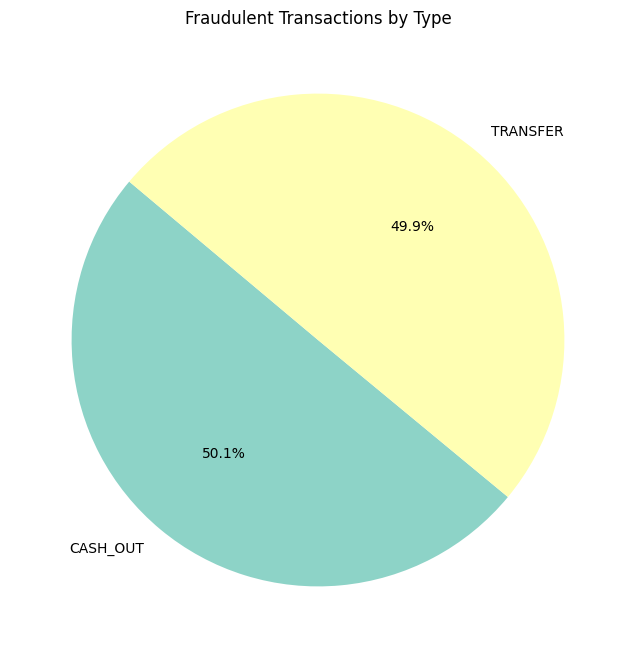

In [16]:
import matplotlib.pyplot as plt

# Filter only fraud transactions
fraud_txn = df[df['isFraud'] == 1]

# Count fraud transactions by type
fraud_by_type = fraud_txn['type'].value_counts()

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(fraud_by_type, labels=fraud_by_type.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title("Fraudulent Transactions by Type")
plt.show()


In [17]:
# Fraud counts by transaction type
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()

print("Fraud transactions by type:")
print(fraud_by_type)


Fraud transactions by type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [18]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [19]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [20]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

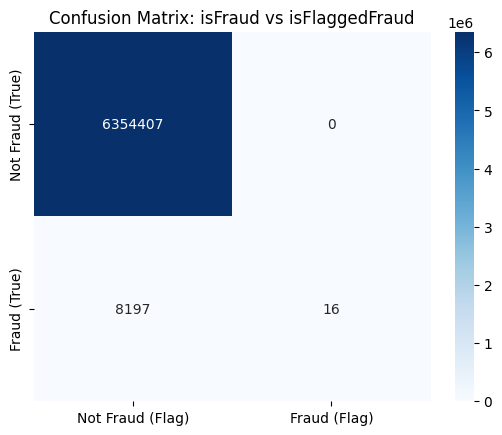

In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['isFraud'], df['isFlaggedFraud'])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Fraud (Flag)", "Fraud (Flag)"],
            yticklabels=["Not Fraud (True)", "Fraud (True)"])
plt.title("Confusion Matrix: isFraud vs isFlaggedFraud")
plt.show()


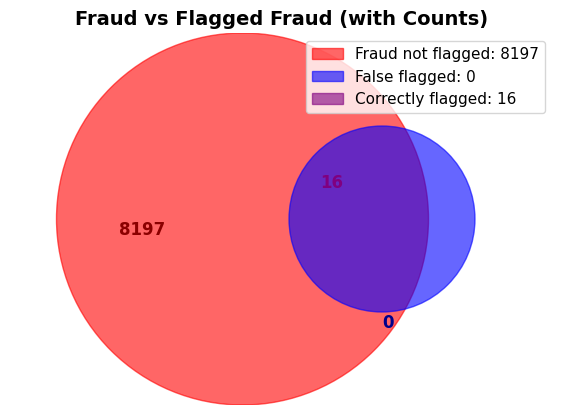

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Correct numbers from confusion matrix
fraud_total = 8197 + 16   # total actual fraud
fraud_not_flagged = 8197  # FN
correctly_flagged = 16    # TP
false_flagged = 0         # FP

# Create plot
fig, ax = plt.subplots(figsize=(7,7))

# Big circle = all actual fraud
fraud_circle = plt.Circle((0,0), 1.2, color="red", alpha=0.6)
ax.add_patch(fraud_circle)

# Smaller circle = flagged fraud (shifted right so overlap visible)
flagged_circle = plt.Circle((0.9,0), 0.6, color="blue", alpha=0.6)
ax.add_patch(flagged_circle)

# Legend patches
fraud_patch = mpatches.Patch(color="red", alpha=0.6, label=f"Fraud not flagged: {fraud_not_flagged}")
flagged_patch = mpatches.Patch(color="blue", alpha=0.6, label=f"False flagged: {false_flagged}")
overlap_patch = mpatches.Patch(color="purple", alpha=0.6, label=f"Correctly flagged: {correctly_flagged}")

# Add legend
plt.legend(handles=[fraud_patch, flagged_patch, overlap_patch], loc="upper right", fontsize=11)

# Annotations near areas
ax.text(-0.8, -0.1, str(fraud_not_flagged), fontsize=12, color="darkred", weight="bold")
ax.text(0.9, -0.7, str(false_flagged), fontsize=12, color="darkblue", weight="bold")
ax.text(0.5, 0.2, str(correctly_flagged), fontsize=12, color="purple", weight="bold")

# Formatting
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect("equal")
ax.axis("off")

plt.title("Fraud vs Flagged Fraud (with Counts)", fontsize=14, weight="bold")
plt.show()


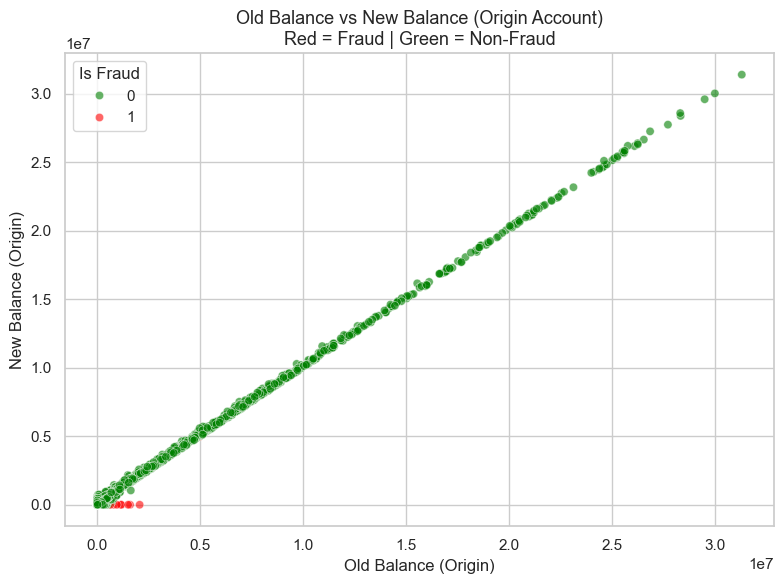

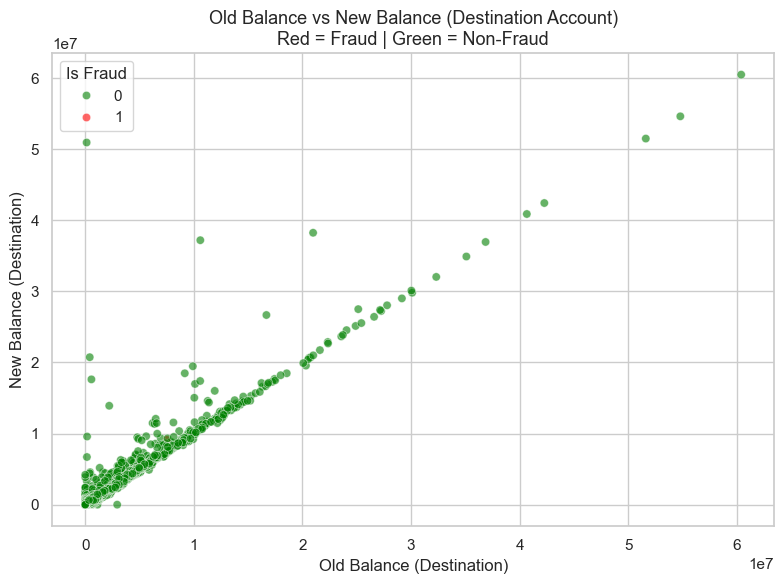

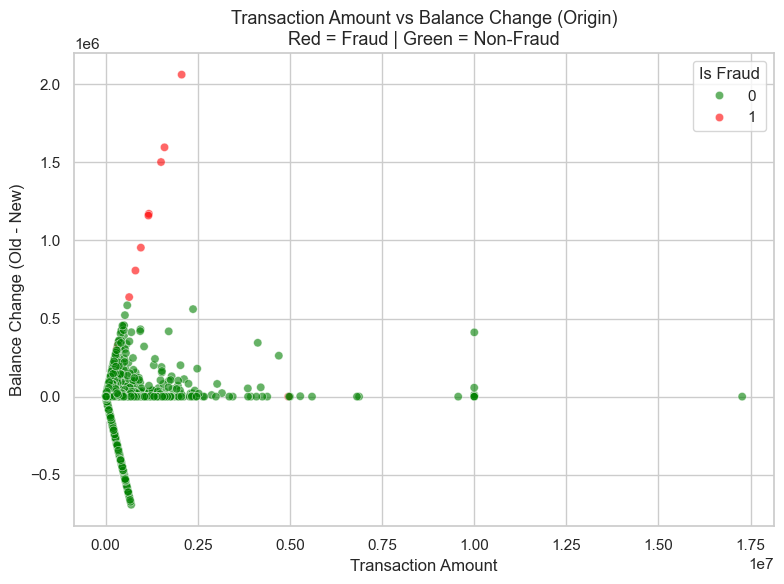

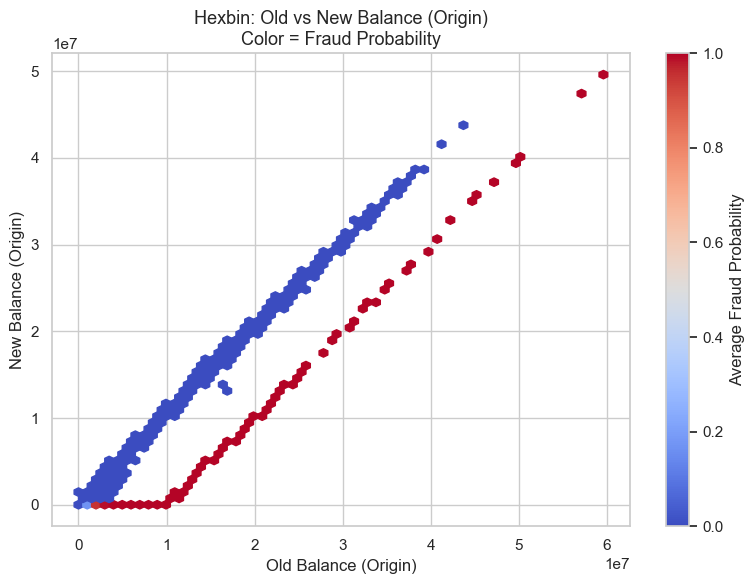

In [32]:

# ✅ Create derived features before sampling
df['balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']

# ✅ Sample a smaller portion for visualization (to reduce clutter)
df_sample = df.sample(8000, random_state=42)

sns.set(style="whitegrid", palette="coolwarm")

# ---------------------------
# 1️⃣ Scatter: oldbalanceOrg vs newbalanceOrig
# ---------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sample,
    x='oldbalanceOrg',
    y='newbalanceOrig',
    hue='isFraud',
    alpha=0.6,
    palette={0: 'green', 1: 'red'}
)
plt.title("Old Balance vs New Balance (Origin Account)\nRed = Fraud | Green = Non-Fraud", fontsize=13)
plt.xlabel("Old Balance (Origin)")
plt.ylabel("New Balance (Origin)")
plt.legend(title='Is Fraud', loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------
# 2️⃣ Scatter: oldbalanceDest vs newbalanceDest
# ---------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sample,
    x='oldbalanceDest',
    y='newbalanceDest',
    hue='isFraud',
    alpha=0.6,
    palette={0: 'green', 1: 'red'}
)
plt.title("Old Balance vs New Balance (Destination Account)\nRed = Fraud | Green = Non-Fraud", fontsize=13)
plt.xlabel("Old Balance (Destination)")
plt.ylabel("New Balance (Destination)")
plt.legend(title='Is Fraud', loc='upper left')
plt.tight_layout()
plt.show()


# ---------------------------
# 3️⃣ Scatter: Transaction Amount vs Balance Change (Origin)
# ---------------------------
# ✅ Ensure balance_change exists in sample
df_sample['balance_change'] = df_sample['oldbalanceOrg'] - df_sample['newbalanceOrig']

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_sample,
    x='amount',
    y='balance_change',
    hue='isFraud',
    alpha=0.6,
    palette={0: 'green', 1: 'red'}
)
plt.title("Transaction Amount vs Balance Change (Origin)\nRed = Fraud | Green = Non-Fraud", fontsize=13)
plt.xlabel("Transaction Amount")
plt.ylabel("Balance Change (Old - New)")
plt.legend(title='Is Fraud', loc='upper right')
plt.tight_layout()
plt.show()


# ---------------------------
# 4️⃣ Hexbin: Old vs New Balance (Origin) - Fraud Intensity
# ---------------------------
plt.figure(figsize=(8,6))
hb = plt.hexbin(
    x=df['oldbalanceOrg'],
    y=df['newbalanceOrig'],
    C=df['isFraud'],
    gridsize=60,
    cmap='coolwarm',
    reduce_C_function=np.mean,  # ✅ compute mean fraud probability
    mincnt=1
)
plt.colorbar(label='Average Fraud Probability')
plt.title("Hexbin: Old vs New Balance (Origin)\nColor = Fraud Probability", fontsize=13)
plt.xlabel("Old Balance (Origin)")
plt.ylabel("New Balance (Origin)")
plt.tight_layout()
plt.show()


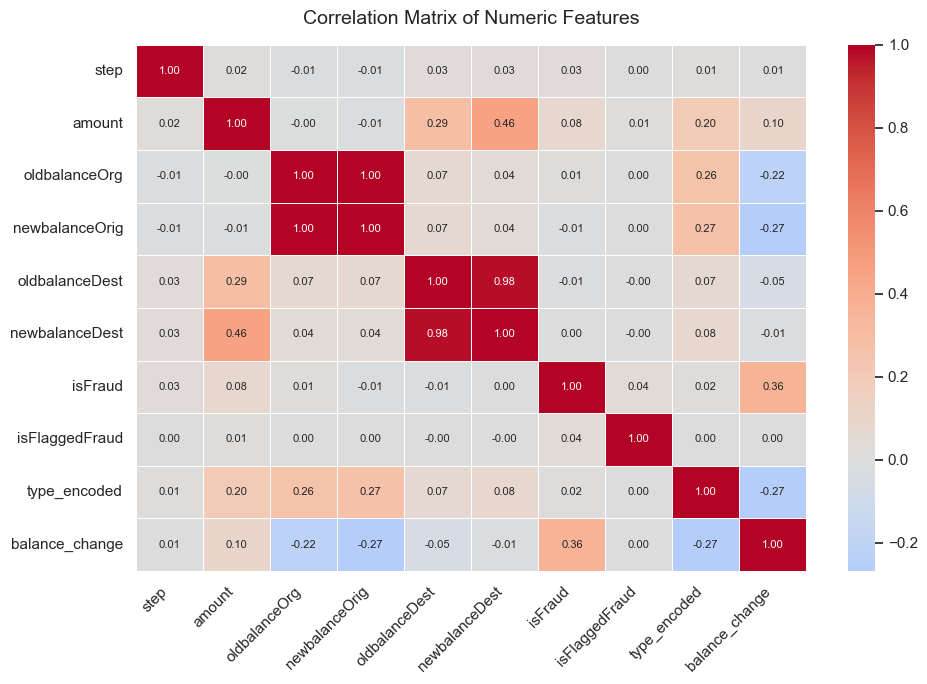


🔍 Top correlations with isFraud:

isFraud           1.000000
balance_change    0.362472
amount            0.076688
isFlaggedFraud    0.044109
step              0.031578
type_encoded      0.016171
oldbalanceOrg     0.010154
newbalanceDest    0.000535
oldbalanceDest   -0.005885
newbalanceOrig   -0.008148
Name: isFraud, dtype: float64


In [ ]:

# -------------------------------
# 1️⃣ Select numeric columns only
# ------------------------------
numeric_df = df.select_dtypes(include=['number'])

# -------------------------------
# 2️⃣ Compute correlation matrix
# -------------------------------
corr_matrix = numeric_df.corr()

# -------------------------------
# 3️⃣ Plot heatmap
# -------------------------------
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,            # Show correlation values
    fmt=".2f",             # Limit decimal places
    cmap="coolwarm",       # Color gradient
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}  # Smaller font size for readability
)

plt.title("Correlation Matrix of Numeric Features", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------
# 4️⃣ Check correlation with isFraud
# -------------------------------
print("\n🔍 Top correlations with isFraud:\n")
print(corr_matrix['isFraud'].sort_values(ascending=False))


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
 11  type_encoded    int64  
 12  balance_change  float64
dtypes: float64(6), int64(4), object(3)
memory usage: 631.1+ MB


In [24]:
# Create time-based features
df['day'] = df['step'] // 24
df['hour'] = df['step'] % 24

# Create categorical time periods
def get_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(get_period)
df.sample(7)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,balance_change,day,hour,time_period
3146489,236,CASH_OUT,277965.48,C788367230,0.0,0.00,C238461736,3549092.92,3827058.40,0,0,0,0.00,9,20,Evening
10637,7,PAYMENT,5412.47,C1330607698,176.0,0.00,M1862112967,0.00,0.00,0,0,1,176.00,0,7,Morning
2264412,187,CASH_OUT,79270.02,C667054109,49725.0,0.00,C1545386657,1433009.73,1443699.25,0,0,0,49725.00,7,19,Evening
3605058,264,PAYMENT,864.06,C1441369645,15690.0,14825.94,M913755667,0.00,0.00,0,0,1,864.06,11,0,Night
2396248,201,CASH_OUT,212772.97,C300045965,0.0,0.00,C1517176843,3008619.63,3221392.61,0,0,0,0.00,8,9,Morning
2747437,212,CASH_OUT,156031.94,C101094868,0.0,0.00,C1883885575,5489373.13,5645405.07,0,0,0,0.00,8,20,Evening
383691,17,CASH_OUT,272650.05,C174528352,0.0,0.00,C539499758,598503.61,871153.66,0,0,0,0.00,0,17,Evening


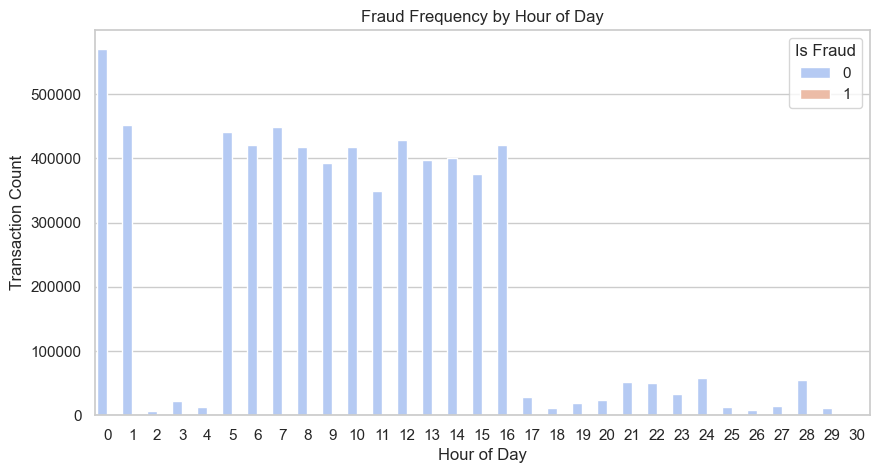

In [26]:
plt.figure(figsize=(10,5))
sns.countplot(x='day', hue='isFraud', data=df, palette='coolwarm')
plt.title("Fraud Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Transaction Count")
plt.legend(title="Is Fraud")
plt.show()


/var/folders/rr/d0gz2wj51xg3h4b_s1cxz0bc0000gn/T/ipykernel_52979/2708970618.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


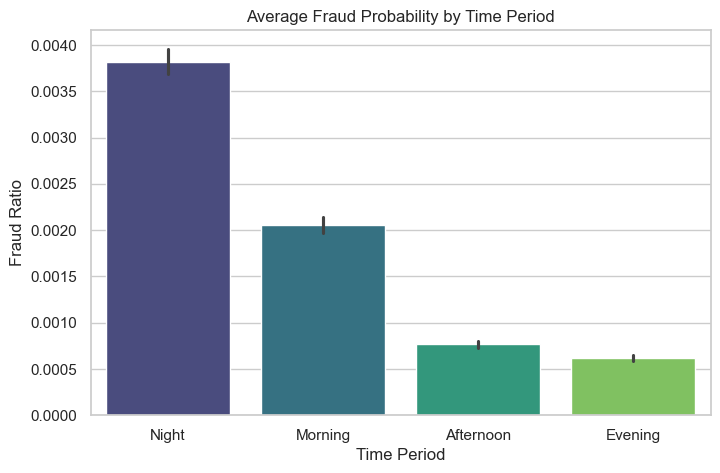

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='time_period',
    y='isFraud',
    data=df,
    estimator='mean',
    palette='viridis'
)
plt.title("Average Fraud Probability by Time Period")
plt.xlabel("Time Period")
plt.ylabel("Fraud Ratio")
plt.show()


/var/folders/rr/d0gz2wj51xg3h4b_s1cxz0bc0000gn/T/ipykernel_52979/612797254.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hour', y='fraud_ratio', data=fraud_ratio, palette='coolwarm')


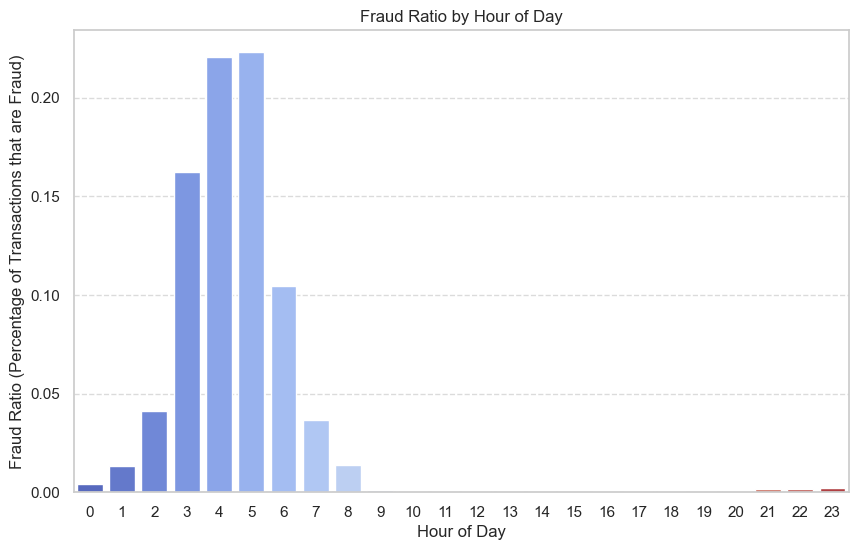

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'hour' exists
df['hour'] = df['step'] % 24

# Calculate fraud ratio per hour
fraud_ratio = (
    df.groupby('hour')['isFraud']
    .mean()
    .reset_index()
    .rename(columns={'isFraud': 'fraud_ratio'})
)

# Plot fraud ratio
plt.figure(figsize=(10,6))
sns.barplot(x='hour', y='fraud_ratio', data=fraud_ratio, palette='coolwarm')
plt.title("Fraud Ratio by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Ratio (Percentage of Transactions that are Fraud)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   step                 int64  
 1   type                 object 
 2   amount               float64
 3   nameOrig             object 
 4   oldbalanceOrg        float64
 5   newbalanceOrig       float64
 6   nameDest             object 
 7   oldbalanceDest       float64
 8   newbalanceDest       float64
 9   isFraud              int64  
 10  isFlaggedFraud       int64  
 11  type_encoded         int64  
 12  balance_change       float64
 13  day                  int64  
 14  hour                 int64  
 15  time_period          object 
 16  dest_balance_change  float64
dtypes: float64(7), int64(6), object(4)
memory usage: 825.2+ MB


In [36]:
time_mapping = {
    'Night': 0,
    'Morning': 1,
    'Afternoon': 2,
    'Evening': 3
}

df['time_period_encoded'] = df['time_period'].map(time_mapping)


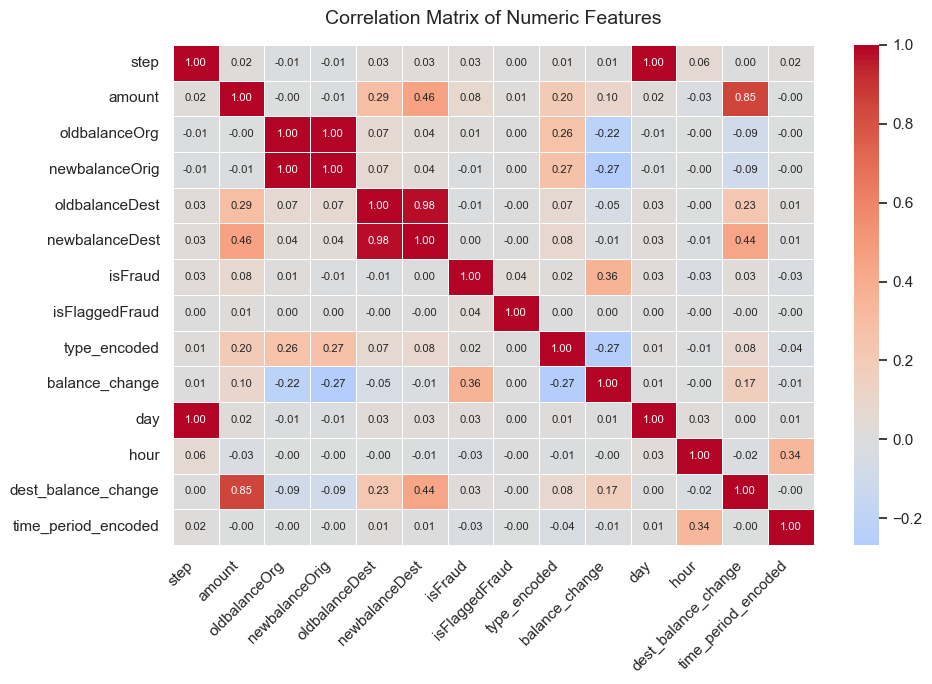


🔍 Top correlations with isFraud:

isFraud                1.000000
balance_change         0.362472
amount                 0.076688
isFlaggedFraud         0.044109
day                    0.032577
step                   0.031578
dest_balance_change    0.027028
type_encoded           0.016171
oldbalanceOrg          0.010154
newbalanceDest         0.000535
oldbalanceDest        -0.005885
newbalanceOrig        -0.008148
time_period_encoded   -0.026281
hour                  -0.031403
Name: isFraud, dtype: float64


In [37]:

# -------------------------------
# 1️⃣ Select numeric columns only
# ------------------------------
numeric_df = df.select_dtypes(include=['number'])

# -------------------------------
# 2️⃣ Compute correlation matrix
# -------------------------------
corr_matrix = numeric_df.corr()

# -------------------------------
# 3️⃣ Plot heatmap
# -------------------------------
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,            # Show correlation values
    fmt=".2f",             # Limit decimal places
    cmap="coolwarm",       # Color gradient
    center=0,
    linewidths=0.5,
    annot_kws={"size": 8}  # Smaller font size for readability
)

plt.title("Correlation Matrix of Numeric Features", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------
# 4️⃣ Check correlation with isFraud
# -------------------------------
print("\n🔍 Top correlations with isFraud:\n")
print(corr_matrix['isFraud'].sort_values(ascending=False))


### **Feature Selection:-**

In [ ]:
df_new = df.drop(["isFraud",])